<a href="https://colab.research.google.com/github/Bonkerzz2603/TH_deaplearn/blob/main/NguyenGiaKhang_ThDeepLearn_tuan2_b1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import keras
from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Dense, Activation
from keras.layers import BatchNormalization, Dropout

In [3]:
image_size = 32
num_channels = 3
num_features = image_size * image_size * num_channels
num_classes = 10

num_train = 49000

In [4]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print(f'Train data shape: {X_train.shape}')
print(f'Test  data shape: {X_test.shape}')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train data shape: (50000, 32, 32, 3)
Test  data shape: (10000, 32, 32, 3)


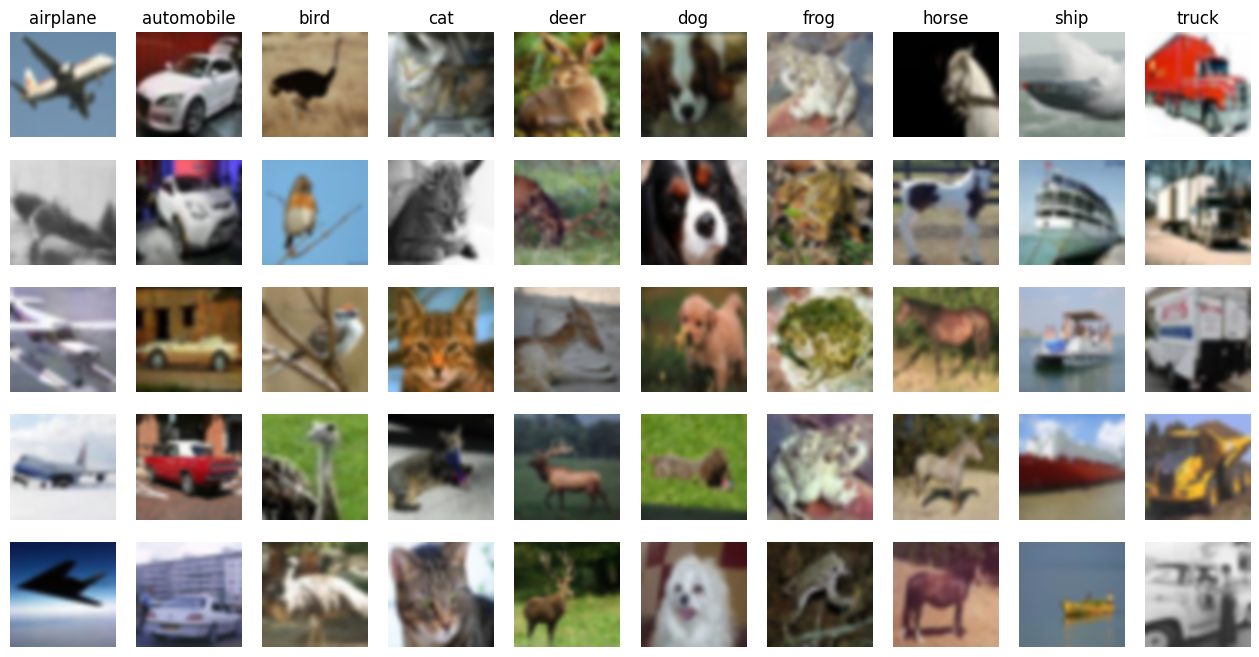

In [5]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
samples_per_class = 5

plt.figure(figsize=(16, 8))

for cls, name in enumerate(class_names):
    idxs = np.flatnonzero(y_train == cls)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + cls + 1 # cls=0 -> (1, 11,...,61), cls=2 -> (2, 12,...,62),...,cls=9 ->(10, 20,...,70)
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx], interpolation='bicubic') # Interpolation used to smooth the appearance of plotted data
        plt.axis('off')
        if i == 0:
            plt.title(class_names[cls])

In [6]:
X_train = X_train.reshape([-1, num_features]) # num_features=3072
X_test  =  X_test.reshape([-1, num_features])

print(f'Train data shape: {X_train.shape}')
print(f'Test  data shape: {X_test.shape}')

Train data shape: (50000, 3072)
Test  data shape: (10000, 3072)


In [7]:
X_train = X_train.astype('float32')
x_test  = X_test.astype('float32')

mu = np.mean(X_train, axis=0)

X_train -= mu
X_train /= 255.0

x_test -= mu
x_test /= 255.0

In [8]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test  = keras.utils.to_categorical(y_test,  num_classes)

print(y_train.shape)
print(y_test.shape)

(50000, 10)
(10000, 10)


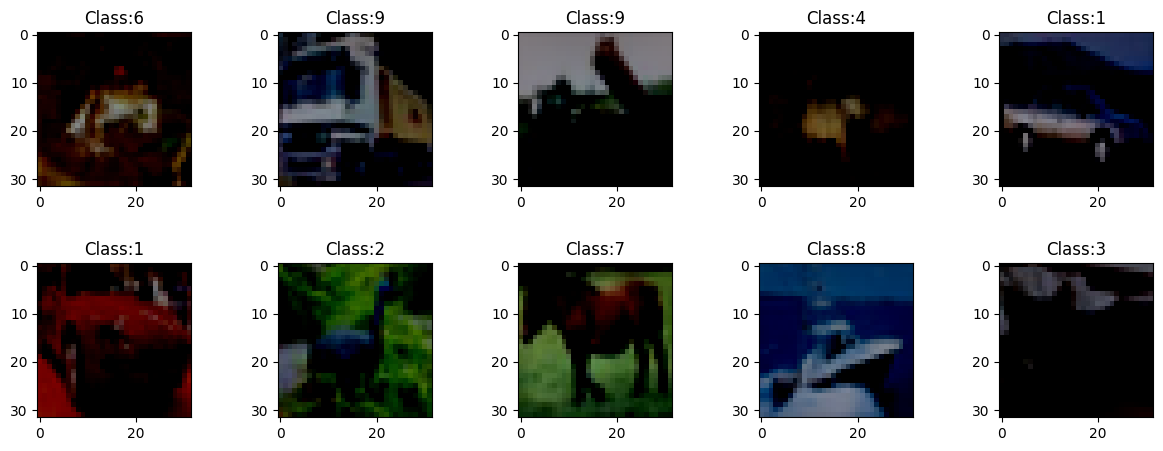

In [9]:
fig,axes = plt.subplots(nrows = 2,ncols=5,figsize=(15,5))
ax = axes.ravel()
for i in range(10):
 ax[i].imshow(X_train[i].reshape(image_size, image_size, num_channels))
 ax[i].set_title('Class:'+str(np.argmax(y_train[i])))
plt.subplots_adjust(hspace = 0.5)
plt.show()

In [10]:
model = Sequential()

# First Hidden Layer
model.add(Dense(units=100, input_shape=(num_features,)))
model.add(BatchNormalization())
model.add(Activation(activation='relu'))
model.add(Dropout(0.2))

# Second Hidden Layer
model.add(Dense(units=100))
model.add(BatchNormalization())
model.add(Activation(activation='relu'))
model.add(Dropout(0.2))

# Output Layer
model.add(Dense(units=num_classes, activation='softmax'))

# print model
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │       307,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,210 (1.22 MB)

 Trainable params: 318,810 (1.22 MB)

 Non-trainable params: 400 (1.56 KB)

In [11]:
model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

In [12]:
optimizer = keras.optimizers.Adam(learning_rate=0.02, decay=1e-6)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [13]:
model.fit(X_train[:num_train], y_train[:num_train],
          batch_size=256,
          epochs=30,
          validation_data=(X_train[num_train:], y_train[num_train:]))

Epoch 1/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.3516 - loss: 1.8010 - val_accuracy: 0.4260 - val_loss: 1.6080
Epoch 2/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.4188 - loss: 1.6169 - val_accuracy: 0.4730 - val_loss: 1.4845
Epoch 3/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4446 - loss: 1.5465 - val_accuracy: 0.4640 - val_loss: 1.4424
Epoch 4/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.4618 - loss: 1.5012 - val_accuracy: 0.4930 - val_loss: 1.3888
Epoch 5/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4748 - loss: 1.4679 - val_accuracy: 0.5150 - val_loss: 1.3552
Epoch 6/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4843 - loss: 1.4373 - val_accuracy: 0.5050 - val_loss: 1.3490
Epoch 7/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.4923 - loss: 1.4083 - val_accuracy: 0.5160 - val_loss: 1.3279
Epoch 8/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5027 - loss: 1.3869 - val_accu

In [14]:
model.evaluate(x_test, y_test, batch_size=256)

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5374 - loss: 1.3020


[1.30202317237854, 0.5374000072479248]

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get predictions from the model
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert y_test from one-hot encoding back to class labels for comparison
y_test_labels = np.argmax(y_test, axis=1)

# Print classification report
print("Classification Report:")
print(classification_report(y_test_labels, y_pred, target_names=class_names))


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
Classification Report:
              precision    recall  f1-score   support

    airplane       0.59      0.61      0.60      1000
  automobile       0.66      0.59      0.62      1000
        bird       0.49      0.35      0.41      1000
         cat       0.35      0.42      0.39      1000
        deer       0.46      0.46      0.46      1000
         dog       0.47      0.41      0.44      1000
        frog       0.56      0.65      0.60      1000
       horse       0.61      0.59      0.60      1000
        ship       0.63      0.69      0.66      1000
       truck       0.56      0.60      0.58      1000

    accuracy                           0.54     10000
   macro avg       0.54      0.54      0.54     10000
weighted avg       0.54      0.54      0.54     10000



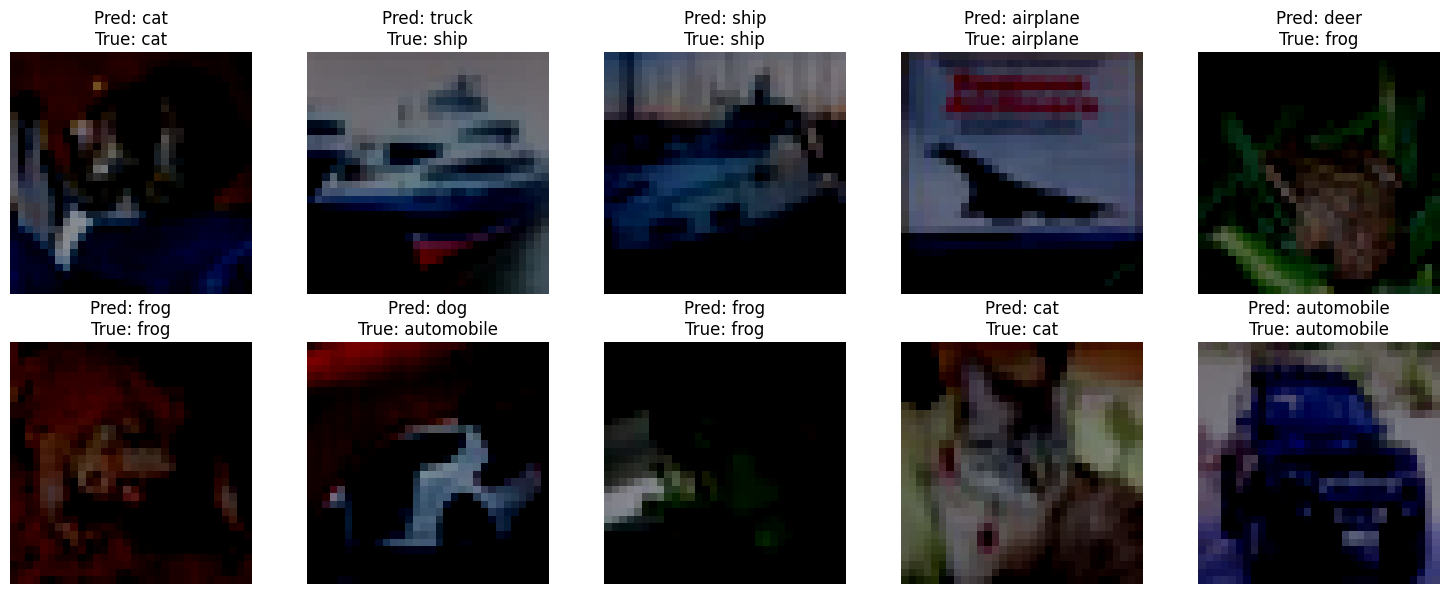

In [16]:
fig,axes = plt.subplots(nrows = 2,ncols=5,figsize=(15,6))
ax = axes.ravel()
for i in range(10):
    # Reshape the flattened image data from x_test back to its original dimensions
    img = x_test[i].reshape(image_size, image_size, num_channels) # image_size=32, num_channels=3
    ax[i].imshow(img) # Display the actual image
    ax[i].set_title(f'Pred: {class_names[y_pred[i]]}\nTrue: {class_names[y_test_labels[i]]}')
    ax[i].axis('off') # Turn off axis labels for cleaner image display
plt.tight_layout() # Adjust subplot params for a tight layout
plt.show()